In [10]:
# alex local filepath - yyou need the path to the h5 files in new_data_sync ( or similar name) on the cluster

combined_filepath = r"c:\Users\Lindsay\Documents\alexander\Deer_project\data\signal_from_cluster\R1_D4_Combined.h5"
combined_filepath = r'/home/geuba03p/deer_accl/R1_D4_Combined.h5'

In [11]:

import pandas as pd



In [12]:
deer_data=pd.read_hdf(combined_filepath)

In [13]:
deer_data.head()

,TagID,X_head,Y_head,Z_head,location-lat,location-lon,DateTime_Global,NZ_DateTime,X_ear,Y_ear,Z_ear
0,AT4 S4Pink 12-13.11_S1,1.9181,-2.3381,5.5481,NaN,NaN,2018-11-11 22:32:20.960,2018-11-12 11:32:20.960,4.468800,-4.703100,-4.171900
1,AT4 S4Pink 12-13.11_S1,-0.4219,-2.9531,4.4531,NaN,NaN,2018-11-11 22:32:20.980,2018-11-12 11:32:20.980,0.309505,-6.302316,1.938201
2,AT4 S4Pink 12-13.11_S1,-2.4531,-3.2500,2.6719,NaN,NaN,2018-11-11 22:32:21.000,2018-11-12 11:32:21.000,-0.844790,-4.678309,4.939194
3,AT4 S4Pink 12-13.11_S1,-2.5450,-3.3725,1.3091,NaN,NaN,2018-11-11 22:32:21.020,2018-11-12 11:32:21.020,-0.765665,-4.018587,6.439003
4,AT4 S4Pink 12-13.11_S1,-2.6069,-3.0300,-0.9537,NaN,NaN,2018-11-11 22:32:21.040,2018-11-12 11:32:21.040,1.381236,-6.008635,6.490636


In [14]:

import math
import numpy as np
from pyproj import Transformer

def load_and_clean_data(filepath,ear=False):
    if not os.path.exists(filepath):
        print(f"Error: Data file {filepath} does not exist.")
        return pd.DataFrame([])
    if ear==False:
        columns_to_keep=['TagID', 'Date', 'Time', 'X', 'Y', 'Z', 'location-lat','location-lon']
    else:
        columns_to_keep=['TagID', 'Date', 'Time', 'X', 'Y', 'Z']
    data=pd.read_csv(filepath,usecols=columns_to_keep)
    data['DateTime_Global'] = pd.to_datetime(data['Date'] + ' ' + data['Time'],format=r"%d/%m/%Y %H:%M:%S.%f")
    data['NZ_DateTime'] = data['DateTime_Global'] + pd.Timedelta(hours=13)
    data.drop(['Date', 'Time'], axis=1, inplace=True)
    return data

def calculate_tortuosity_and_speed(pos_x,pos_y,fps=0.5):
    tortuosity_values = []
    absolute_speeds = [] 
    for i in range(len(pos_x) - 2):

        # Vector norm from the Point 0 to Point 1
        vn1 = np.linalg.norm(np.array([pos_x[i+1],pos_y[i+1]])-np.array([pos_x[i],pos_y[i]]))
        
        # Vector norm from the Point 1 to Point 2
        vn2 = np.linalg.norm(np.array([pos_x[i+2],pos_y[i+2]])-np.array([pos_x[i+1],pos_y[i+1]]))
        
        # Vector norm from the Point 0 to Point 2
        vn = np.linalg.norm(np.array([pos_x[i+2],pos_y[i+2]])-np.array([pos_x[i],pos_y[i]]))
        
        #Save to speeds
        absolute_speeds.append(vn1/fps)
        
        # Handle division by zero and save tortuosity
        if vn2 + vn1 == 0:
            tortuosity_values.append(0)  # or any other default value
        else:
            tortuosity_values.append(vn / (vn2 + vn1))
    
    #get last absolute speed        
    i += 1
    # Vector norm from the Poitn 0 to Point 1
    vn1 = lat_lon_vec_to_meter_vec(pos_x[i],pos_y[i],pos_x[i+1],pos_y[i+1])
    absolute_speeds.append(vn1/fps)
        
    tortuosity_values.insert(0, tortuosity_values[0]) # append 2 zeros for the end 
    tortuosity_values.append(tortuosity_values[-1])
    absolute_speeds.insert(0, absolute_speeds[0]) 
    return {"tortuosity":tortuosity_values,"speed": absolute_speeds}



def project_to_NZ_map_grid(lats,lons):
    # ("EPSG:4326") : LatLon with WGS84 datum used by GPS units and Google Earth 
    # ("EPSG:27200") : New Zealad Map Grid of the E_uropean P_etroleum S_urvey G_roup
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:27200")
    xx, yy = transformer.transform(lats, lons)  
    return xx,yy

In [18]:
pos_data = deer_data.loc[:,['location-lat','location-lon']].copy()
pos_data = pos_data.dropna()
pos_x_meter,pos_y_meter = project_to_NZ_map_grid(pos_data['location-lat'].to_numpy(),
                                             pos_data['location-lon'].to_numpy())

pos_data['pos_x_meter'] = pos_x_meter
pos_data["pos_y_meter"] = pos_y_meter


pos_data.head()

,location-lat,location-lon,pos_x_meter,pos_y_meter
52,-38.11025,175.49809,2.729201e+06,6.340619e+06
152,-38.11027,175.49807,2.729199e+06,6.340617e+06
252,-38.11028,175.49807,2.729199e+06,6.340615e+06
352,-38.11027,175.49807,2.729199e+06,6.340617e+06
452,-38.11029,175.49808,2.729200e+06,6.340614e+06


In [19]:
original_deer_data=deer_data.loc[:,['location-lat','location-lon']].copy()

pos_data['pos_x_meter'] = np.nan
pos_data["pos_y_meter"] = np.nan
original_deer_data.update(pos_data)

print(original_deer_data.iloc[140:160,:])

     location-lat  location-lon
140           NaN           NaN
141           NaN           NaN
142           NaN           NaN
143           NaN           NaN
144           NaN           NaN
145           NaN           NaN
146           NaN           NaN
147           NaN           NaN
148           NaN           NaN
149           NaN           NaN
150           NaN           NaN
151           NaN           NaN
152     -38.11027     175.49807
153           NaN           NaN
154           NaN           NaN
155           NaN           NaN
156           NaN           NaN
157           NaN           NaN
158           NaN           NaN
159           NaN           NaN


In [64]:
deer_data_interpolated=original_deer_data.copy()
deer_data_interpolated.interpolate(method='linear', inplace=True)

# Forward fill and backward fill
deer_data_interpolated.ffill(inplace=True)
deer_data_interpolated.bfill(inplace=True)

     location-lat  location-lon  tortuosity  absolute_speed
140    -38.110268    175.498072    0.955656        5.665876
141    -38.110268    175.498072    0.955656        5.665876
142    -38.110268    175.498072    0.955656        5.665876
143    -38.110268    175.498072    0.955656        5.665876
144    -38.110268    175.498072    0.955656        5.665876
145    -38.110269    175.498071    0.955656        5.665876
146    -38.110269    175.498071    0.955656        5.665876
147    -38.110269    175.498071    0.955656        5.665876
148    -38.110269    175.498071    0.955656        5.665876
149    -38.110269    175.498071    0.955656        5.665876
150    -38.110270    175.498070    0.955656        5.665876
151    -38.110270    175.498070    0.955656        5.665876
152    -38.110270    175.498070    0.955656        5.665876
153    -38.110270    175.498070    0.946100        5.631481
154    -38.110270    175.498070    0.936543        5.597086
155    -38.110270    175.498070    0.926

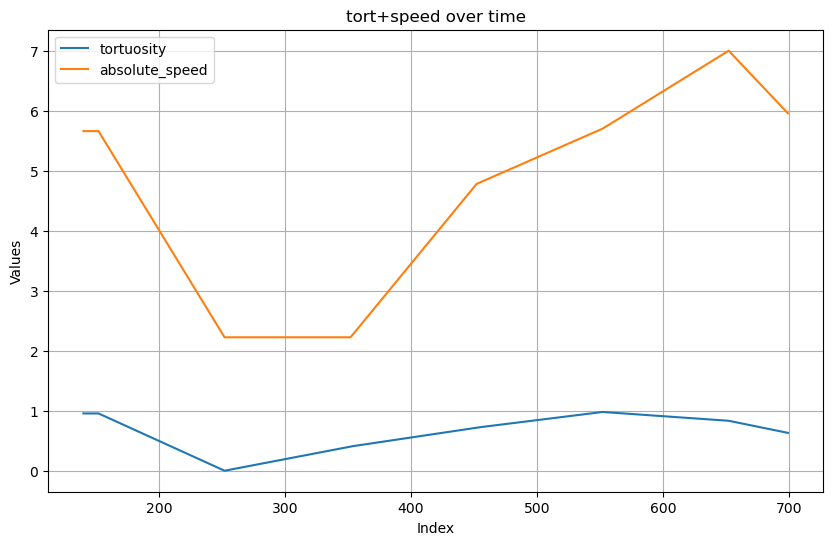

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the first 10000 rows
data_subset = deer_data_interpolated.iloc[140:700]

# Create a line plot for all four columns
data_subset.plot(y=[ 'tortuosity', 'absolute_speed'], figsize=(10, 6))

# Customize the plot (optional)
plt.title('tort+speed over time')  # Change title to 'Change' in Japanese
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Display the 

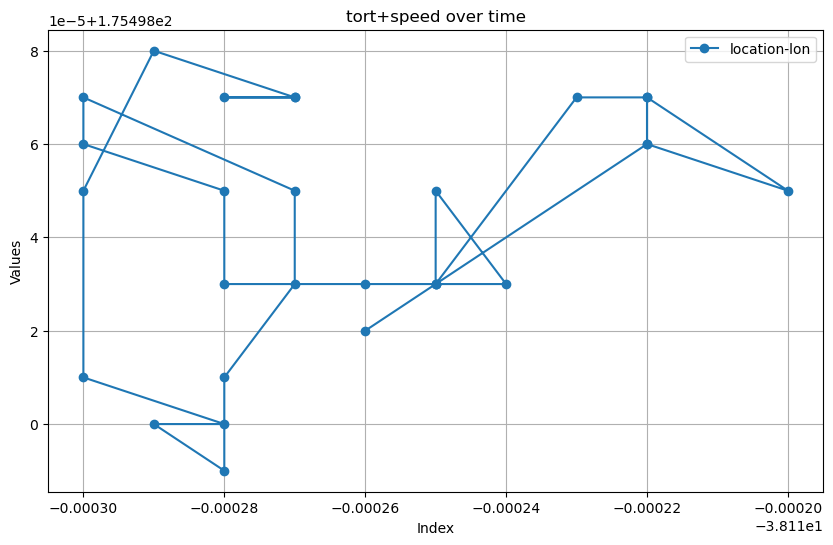

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the first 10000 rows
data_subset = pos_data.iloc[1:30]
#data_subset=deer_data_interpolated.iloc[152:2000]
# Create a line plot for all four columns
data_subset.plot( 'location-lat', 'location-lon', figsize=(10, 6), marker = "o")

# Customize the plot (optional)
plt.title('tort+speed over time')  # Change title to 'Change' in Japanese
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (replace 'data.csv' with your file path)
data = pos_data.iloc[1:600].copy()
# Calculate moving average for latitude and longitude with window size of 30
window_size = 5
data['avg_lat'] = data['location-lat'].rolling(window=window_size).mean()
data['avg_lon'] = data['location-lon'].rolling(window=window_size).mean()


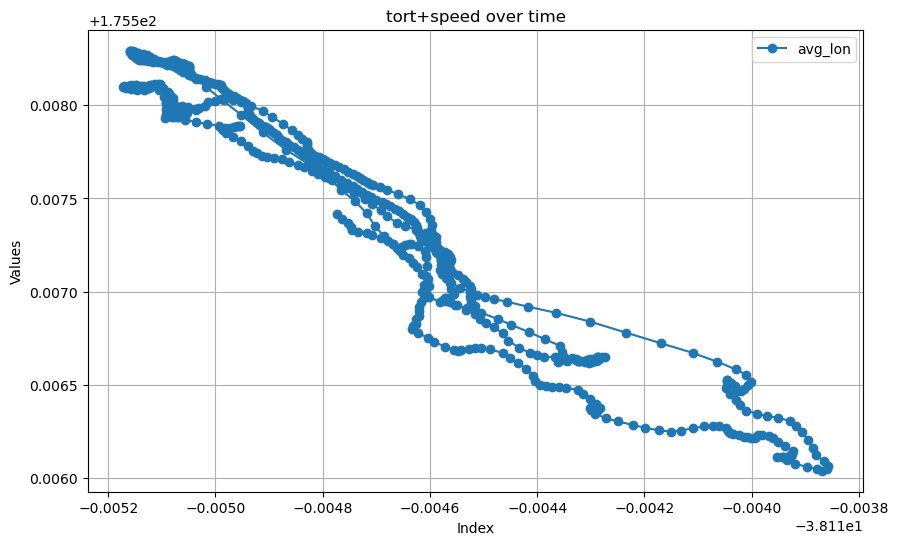

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the first 10000 rows
data_subset = data
#data_subset=deer_data_interpolated.iloc[152:2000]
# Create a line plot for all four columns
data_subset.plot( 'avg_lat', 'avg_lon', figsize=(10, 6), marker = "o")

# Customize the plot (optional)
plt.title('tort+speed over time')  # Change title to 'Change' in Japanese
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

/tmp/ipykernel_5779/4125127242.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=data['avg_lon'], y=data['avg_lat'], cmap='viridis', shade=True, cbar=True)
/home/geuba03p/miniconda3/envs/deer_project_2/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/geuba03p/miniconda3/envs/deer_project_2/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/geuba03p/miniconda3/envs/deer_project_2/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is 

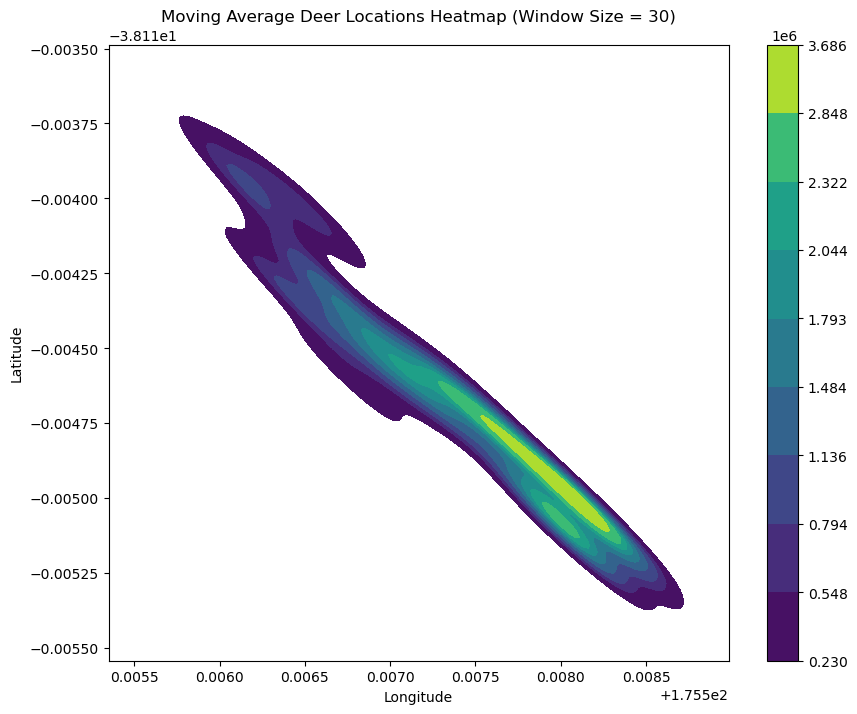

In [42]:

# Create heatmap using Seaborn with moving average
plt.figure(figsize=(10, 8))
sns.kdeplot(x=data['avg_lon'], y=data['avg_lat'], cmap='viridis', shade=True, cbar=True)
plt.title('Moving Average Deer Locations Heatmap (Window Size = 30)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# check it worked with plots
then run on all data

In [43]:
# tort_and_speed=calculate_tortuosity_and_speed(deer_data_interpolated['location-lat'], deer_data_interpolated['location-lon'])

# deer_data_interpolated['tortuosity']= tort_and_speed['tortuosity']
# deer_data_interpolated["absolute_speed"]= tort_and_speed["speed"]

# Heatmap of deer position

/tmp/ipykernel_5779/994544155.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=data['location-lon'], y=data['location-lat'], cmap='viridis', shade=True, cbar=True)
/home/geuba03p/miniconda3/envs/deer_project_2/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/geuba03p/miniconda3/envs/deer_project_2/lib/python3.12/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/geuba03p/miniconda3/envs/deer_project_2/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na 

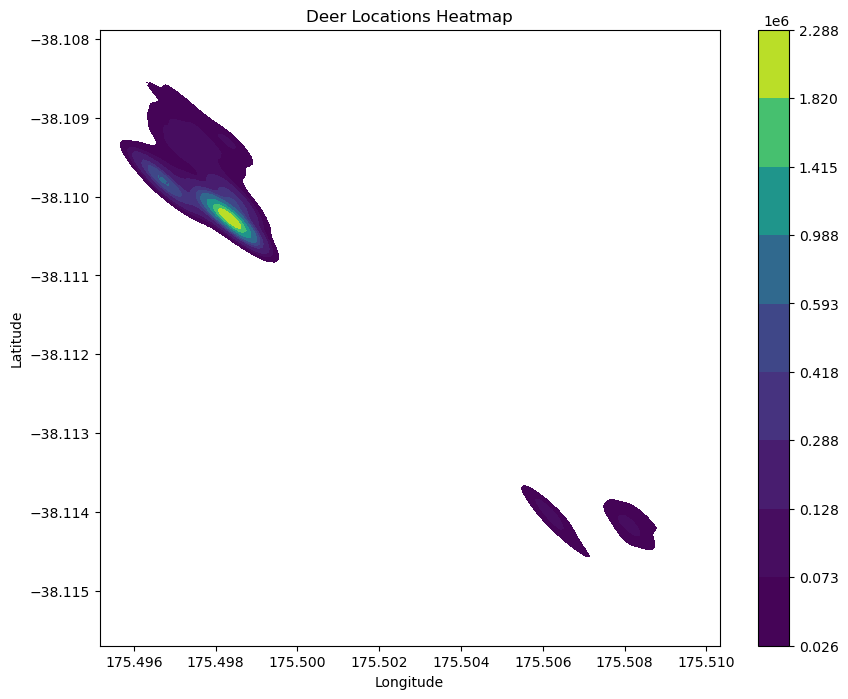

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (replace 'data.csv' with your file path)
data = pos_data
# Create heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.kdeplot(x=data['location-lon'], y=data['location-lat'], cmap='viridis', shade=True, cbar=True)
plt.title('Deer Locations Heatmap')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
